In [0]:
storage_account_name = "amazondatalake60304948"
storage_account_key = "t8pg68f8Wo84sAYKeZ6k8wDm/X2WOYuUcRLMwcRo2UTs/lyzH8ok/m2c/hJPg7LZ3cRp/kD3y/Gp+ASt4JvYPw=="

spark.conf.set(
  f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
  storage_account_key)

In [0]:
train_path = "abfss://raw@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/train_FD001.txt"
test_path  = "abfss://raw@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/test_FD001.txt"
rul_path   = "abfss://raw@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/RUL_FD001.txt"

In [0]:
train_df = spark.read.option("inferSchema", "true").option("sep", " ").csv(train_path)
test_df = spark.read.option("inferSchema", "true").option("sep", " ").csv(test_path)
rul_df = spark.read.option("inferSchema", "true").option("sep", " ").csv(rul_path)

In [0]:
train_df.printSchema()
test_df.printSchema()
rul_df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- _c1: integer (nullable = true)
 |-- _c2: double (nullable = true)
 |-- _c3: double (nullable = true)
 |-- _c4: double (nullable = true)
 |-- _c5: double (nullable = true)
 |-- _c6: double (nullable = true)
 |-- _c7: double (nullable = true)
 |-- _c8: double (nullable = true)
 |-- _c9: double (nullable = true)
 |-- _c10: double (nullable = true)
 |-- _c11: double (nullable = true)
 |-- _c12: double (nullable = true)
 |-- _c13: double (nullable = true)
 |-- _c14: double (nullable = true)
 |-- _c15: double (nullable = true)
 |-- _c16: double (nullable = true)
 |-- _c17: double (nullable = true)
 |-- _c18: double (nullable = true)
 |-- _c19: double (nullable = true)
 |-- _c20: double (nullable = true)
 |-- _c21: integer (nullable = true)
 |-- _c22: integer (nullable = true)
 |-- _c23: double (nullable = true)
 |-- _c24: double (nullable = true)
 |-- _c25: double (nullable = true)
 |-- _c26: string (nullable = true)
 |-- _c27: string (nullable =

In [0]:
# The text files have extra blank columns at the end because of trailing spaces
# In your loaded Spark DataFrame, these appeared as _c26 and _c27
# We remove them because they contain only NULL values and are not real features

train_df = train_df.drop("_c26", "_c27")
test_df = test_df.drop("_c26", "_c27")

In [0]:
# Create a Python list with the real column names of the turbofan dataset
# The dataset structure is:
# 1) unit_number
# 2) time_in_cycles
# 3) 3 operating settings
# 4) 21 sensor measurements

columns = (
    ["unit_number", "time_in_cycles"] +            # first 2 columns
    ["op_setting_1", "op_setting_2", "op_setting_3"] +   # next 3 columns
    [f"sensor_{i}" for i in range(1, 22)]          # sensor_1 to sensor_21
)

In [0]:
# Replace the automatic Spark column names (_c0, _c1, _c2, ...)
# with the real names stored in the list called 'columns'

train_df = train_df.toDF(*columns)
test_df = test_df.toDF(*columns)

# Rename the RUL file column
rul_df = rul_df.toDF("RUL")

In [0]:
# Print the schema to check that the renaming worked correctly
# You should now see meaningful names instead of _c0, _c1, _c2 ...

train_df.printSchema()

# Show the first 5 rows after renaming the columns
display(train_df.limit(5))

root
 |-- unit_number: integer (nullable = true)
 |-- time_in_cycles: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: integer (nullable = true)
 |-- sensor_19: double (nullable = true)


unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
1,1,-7.0E-4,-4.0E-4,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
1,2,0.0019,-3.0E-4,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
1,3,-0.0043,3.0E-4,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
1,4,7.0E-4,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
1,5,-0.0019,-2.0E-4,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


In [0]:
# Import the functions we need for validation
from pyspark.sql.functions import col, sum

# Create cleaned copies of the train and test datasets
clean_train_df = train_df
clean_test_df = test_df

# Remove duplicate rows if any exist
clean_train_df = clean_train_df.dropDuplicates()
clean_test_df = clean_test_df.dropDuplicates()

# Count missing values in each column of the training dataset
clean_train_df.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in clean_train_df.columns]
).show()

# Count missing values in each column of the test dataset
clean_test_df.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in clean_test_df.columns]
).show()

# Print the number of rows after cleaning
print("Train rows after cleaning:", clean_train_df.count())
print("Test rows after cleaning:", clean_test_df.count())

# Preview the cleaned training dataset
display(clean_train_df.limit(5))

+-----------+--------------+------------+------------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|op_setting_1|op_setting_2|op_setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|sensor_6|sensor_7|sensor_8|sensor_9|sensor_10|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_16|sensor_17|sensor_18|sensor_19|sensor_20|sensor_21|
+-----------+--------------+------------+------------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|          0|             0|           0|           0|           0|       0|       0|       0|       0|       0|       0|       0|       0|       0|        0|        0|        0|        0|     

unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
1,157,-0.0018,2.0E-4,100.0,518.67,642.2,1598.04,1412.47,14.62,21.61,552.32,2388.14,9053.12,1.3,47.72,520.94,2388.17,8125.07,8.4328,0.03,392,2388,100.0,38.67,23.2354
2,161,-0.0031,3.0E-4,100.0,518.67,642.08,1586.65,1396.32,14.62,21.61,554.18,2388.05,9057.22,1.3,47.19,521.96,2388.04,8140.21,8.4601,0.03,393,2388,100.0,38.83,23.4036
3,20,-0.002,-2.0E-4,100.0,518.67,642.25,1580.73,1394.57,14.62,21.61,554.54,2388.06,9047.08,1.3,47.1,522.29,2388.03,8135.13,8.398,0.03,391,2388,100.0,38.93,23.3357
3,75,-7.0E-4,-2.0E-4,100.0,518.67,642.25,1592.23,1406.98,14.62,21.61,553.73,2388.05,9059.09,1.3,47.25,522.24,2387.99,8144.98,8.4043,0.03,392,2388,100.0,39.1,23.41
5,47,2.0E-4,-2.0E-4,100.0,518.67,641.95,1579.17,1397.44,14.62,21.6,554.74,2388.0,9068.21,1.3,47.05,522.57,2388.0,8147.3,8.4182,0.03,391,2388,100.0,39.06,23.4378


In [0]:
# Define output paths in the processed container
clean_train_path = "abfss://processed@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/clean_train/"
clean_test_path = "abfss://processed@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/clean_test/"
rul_output_path = "abfss://processed@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/rul/"

# Save the cleaned training dataset as parquet
clean_train_df.write.mode("overwrite").parquet(clean_train_path)

# Save the cleaned test dataset as parquet
clean_test_df.write.mode("overwrite").parquet(clean_test_path)

In [0]:
# Reload the parquet files from the processed container to verify they were saved correctly
train_silver_df = spark.read.parquet(clean_train_path)
test_silver_df = spark.read.parquet(clean_test_path)
rul_silver_df = spark.read.parquet(rul_output_path)

print("Clean train rows:", train_silver_df.count())
print("Clean test rows:", test_silver_df.count())
print("RUL rows:", rul_silver_df.count())

display(train_silver_df.limit(5))

Clean train rows: 20631
Clean test rows: 13096
RUL rows: 100


unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
37,120,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364
37,122,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487
38,35,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355
38,86,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219
39,65,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279


In [0]:
from pyspark.sql.functions import max, col

# Find the maximum cycle reached by each engine in the training set
max_cycle_df = train_silver_df.groupBy("unit_number").agg(
    max("time_in_cycles").alias("max_cycle")
)

# Join the maximum cycle back to each row of the training data
train_with_max_df = train_silver_df.join(max_cycle_df, on="unit_number", how="left")

# Create the Remaining Useful Life (RUL) column
# RUL = last cycle of that engine - current cycle
train_rul_df = train_with_max_df.withColumn(
    "RUL",
    col("max_cycle") - col("time_in_cycles")
)

# Preview the enriched dataset
train_rul_df.printSchema()
display(train_rul_df.limit(5))

root
 |-- unit_number: integer (nullable = true)
 |-- time_in_cycles: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: integer (nullable = true)
 |-- sensor_19: double (nullable = true)


unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
37,120,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364,170,50
37,122,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487,170,48
38,35,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355,194,159
38,86,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219,194,108
39,65,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279,128,63


In [0]:
# Check a few rows for one engine to confirm RUL decreases correctly
display(
    train_rul_df.filter(col("unit_number") == 1)
    .select("unit_number", "time_in_cycles", "max_cycle", "RUL")
    .limit(10)
)

unit_number,time_in_cycles,max_cycle,RUL
1,157,192,35
1,123,192,69
1,8,192,184
1,147,192,45
1,70,192,122
1,90,192,102
1,161,192,31
1,80,192,112
1,7,192,185
1,82,192,110


In [0]:
# Save the training dataset with the new RUL column
train_rul_path = "abfss://processed@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/train_with_rul/"

train_rul_df.write.mode("overwrite").parquet(train_rul_path)

In [0]:
# Reload the dataset with RUL to confirm it was saved correctly
train_rul_check_df = spark.read.parquet(train_rul_path)

print("Train with RUL rows:", train_rul_check_df.count())
display(train_rul_check_df.limit(5))

Train with RUL rows: 20631


unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
37,120,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364,170,50
37,122,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487,170,48
38,35,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355,194,159
38,86,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219,194,108
39,65,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279,128,63


In [0]:
# Load the enriched training dataset with RUL
train_rul_path = "abfss://processed@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/train_with_rul/"
train_rul_df = spark.read.parquet(train_rul_path)

print("Rows:", train_rul_df.count())
display(train_rul_df.limit(5))

Rows: 20631


unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
37,120,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364,170,50
37,122,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487,170,48
38,35,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355,194,159
38,86,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219,194,108
39,65,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279,128,63


In [0]:
# Check schema
train_rul_df.printSchema()

# Count number of engines
print("Number of engines:", train_rul_df.select("unit_number").distinct().count())

# Check cycle range
from pyspark.sql.functions import min, max

train_rul_df.select(
    min("time_in_cycles").alias("min_cycle"),
    max("time_in_cycles").alias("max_cycle"),
    min("RUL").alias("min_rul"),
    max("RUL").alias("max_rul")
).show()

root
 |-- unit_number: integer (nullable = true)
 |-- time_in_cycles: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: integer (nullable = true)
 |-- sensor_19: double (nullable = true)


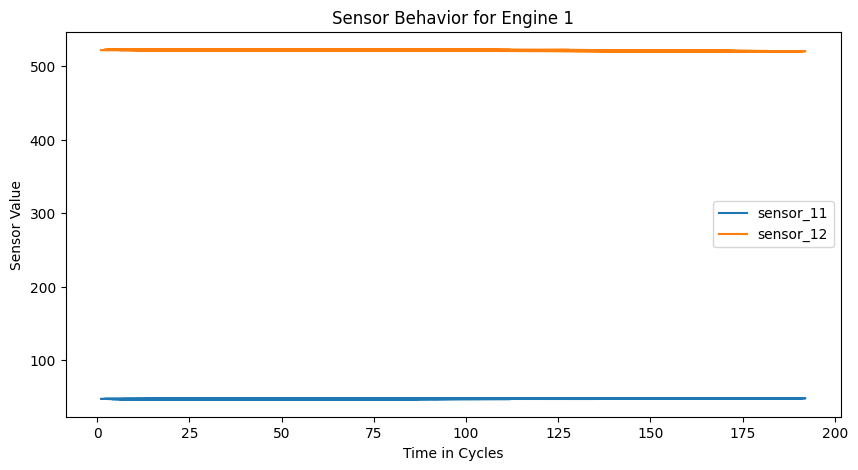

In [0]:
# Convert one engine to pandas for plotting
engine_1_df = (
    train_rul_df
    .filter(train_rul_df.unit_number == 1)
    .select("time_in_cycles", "sensor_11", "sensor_12", "RUL")
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(engine_1_df["time_in_cycles"], engine_1_df["sensor_11"], label="sensor_11")
plt.plot(engine_1_df["time_in_cycles"], engine_1_df["sensor_12"], label="sensor_12")
plt.xlabel("Time in Cycles")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior for Engine 1")
plt.legend()
plt.show()

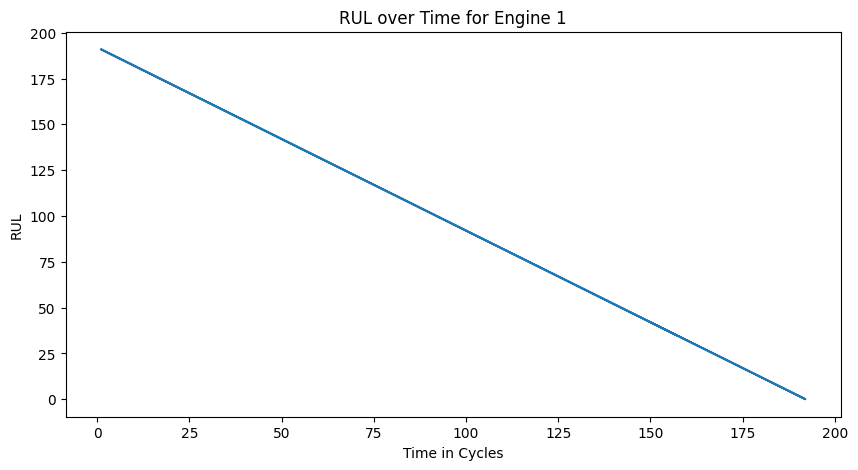

In [0]:
plt.figure(figsize=(10,5))
plt.plot(engine_1_df["time_in_cycles"], engine_1_df["RUL"])
plt.xlabel("Time in Cycles")
plt.ylabel("RUL")
plt.title("RUL over Time for Engine 1")
plt.show()

In [0]:
# Keep the columns needed for predictive maintenance feature extraction
feature_input_df = train_rul_df.select(
    "unit_number",
    "time_in_cycles",
    "RUL",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    *[f"sensor_{i}" for i in range(1, 22)]
)

display(feature_input_df.limit(5))

unit_number,time_in_cycles,RUL,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
37,120,50,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364
37,122,48,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487
38,35,159,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355
38,86,108,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219
39,65,63,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279


In [0]:
# Save the enriched model-ready dataset to the curated (Gold) layer
gold_path = "abfss://curated@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/features_v1/"

feature_input_df.write.mode("overwrite").parquet(gold_path)

In [0]:
gold_df = spark.read.parquet(gold_path)

gold_df.printSchema()
print("Final row count:", gold_df.count())
display(gold_df.limit(5))

root
 |-- unit_number: integer (nullable = true)
 |-- time_in_cycles: integer (nullable = true)
 |-- RUL: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: integer (nullable = true)
 |-- 

unit_number,time_in_cycles,RUL,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
37,120,50,-0.003,-3.0E-4,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364
37,122,48,-0.0014,-2.0E-4,100.0,518.67,643.05,1582.08,1411.7,14.62,21.61,553.0,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487
38,35,159,0.0024,2.0E-4,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355
38,86,108,0.0016,-4.0E-4,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.1,9057.41,1.3,47.57,521.2,2388.1,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219
39,65,63,-0.0017,2.0E-4,100.0,518.67,642.8,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279


In [0]:
# Convert the Spark dataframe to pandas because tsfresh works with pandas
gold_pd = gold_df.toPandas()

print("Gold pandas shape:", gold_pd.shape)
gold_pd.head()

Gold pandas shape: (20631, 27)


,unit_number,time_in_cycles,RUL,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,37,120,50,-0.0030,-0.0003,100.0,518.67,642.95,1594.96,1413.22,14.62,21.61,552.28,2388.18,9041.93,1.3,47.69,520.82,2388.12,8125.52,8.4661,0.03,394,2388,100.0,38.81,23.1364
1,37,122,48,-0.0014,-0.0002,100.0,518.67,643.05,1582.08,1411.70,14.62,21.61,553.00,2388.19,9037.21,1.3,47.89,520.67,2388.16,8117.92,8.4625,0.03,394,2388,100.0,38.87,23.2487
2,38,35,159,0.0024,0.0002,100.0,518.67,641.88,1583.35,1408.37,14.62,21.61,553.15,2388.13,9044.18,1.3,47.52,521.58,2388.08,8129.72,8.4148,0.03,392,2388,100.0,38.86,23.3355
3,38,86,108,0.0016,-0.0004,100.0,518.67,643.23,1584.84,1407.81,14.62,21.61,552.76,2388.10,9057.41,1.3,47.57,521.20,2388.10,8133.92,8.4246,0.03,393,2388,100.0,38.73,23.2219
4,39,65,63,-0.0017,0.0002,100.0,518.67,642.80,1594.73,1415.16,14.62,21.61,553.53,2388.16,9041.59,1.3,47.63,521.01,2388.12,8128.29,8.4408,0.03,394,2388,100.0,38.95,23.2279


In [0]:
# Sort by engine and cycle so each engine's time series is in the correct order
gold_pd = gold_pd.sort_values(["unit_number", "time_in_cycles"]).reset_index(drop=True)

gold_pd.head()

,unit_number,time_in_cycles,RUL,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,191,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,190,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,189,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,188,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,187,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [0]:
# Keep the target and all time-series input columns
feature_cols = (
    ["unit_number", "time_in_cycles", "RUL",
     "op_setting_1", "op_setting_2", "op_setting_3"] +
    [f"sensor_{i}" for i in range(1, 22)]
)

gold_pd = gold_pd[feature_cols]

print(gold_pd.shape)
gold_pd.head()

(20631, 27)


,unit_number,time_in_cycles,RUL,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,191,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,190,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,189,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,188,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,187,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [0]:
import time
start_time = time.time()

In [0]:
%pip install tsfresh

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters

# Remove the target before feature extraction
tsfresh_input = gold_pd.drop(columns=["RUL"])

# Extract features for each engine using time_in_cycles as the time index
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="unit_number",
    column_sort="time_in_cycles",
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0
)

# Fill any missing feature values created during extraction
impute(tsfresh_features)

print("Extracted feature matrix shape:", tsfresh_features.shape)
tsfresh_features.head()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Feature Extraction: 100%|██████████| 2400/2400 [00:08<00:00, 274.66it/s]


Extracted feature matrix shape: (100, 240)


,op_setting_1__sum_values,op_setting_1__median,op_setting_1__mean,op_setting_1__length,op_setting_1__standard_deviation,op_setting_1__variance,op_setting_1__root_mean_square,op_setting_1__maximum,op_setting_1__absolute_maximum,op_setting_1__minimum,op_setting_2__sum_values,op_setting_2__median,op_setting_2__mean,op_setting_2__length,op_setting_2__standard_deviation,op_setting_2__variance,op_setting_2__root_mean_square,op_setting_2__maximum,op_setting_2__absolute_maximum,op_setting_2__minimum,op_setting_3__sum_values,op_setting_3__median,op_setting_3__mean,op_setting_3__length,op_setting_3__standard_deviation,op_setting_3__variance,op_setting_3__root_mean_square,op_setting_3__maximum,op_setting_3__absolute_maximum,op_setting_3__minimum,sensor_1__sum_values,sensor_1__median,sensor_1__mean,sensor_1__length,sensor_1__standard_deviation,sensor_1__variance,sensor_1__root_mean_square,sensor_1__maximum,sensor_1__absolute_maximum,sensor_1__minimum,...,sensor_18__sum_values,sensor_18__median,sensor_18__mean,sensor_18__length,sensor_18__standard_deviation,sensor_18__variance,sensor_18__root_mean_square,sensor_18__maximum,sensor_18__absolute_maximum,sensor_18__minimum,sensor_19__sum_values,sensor_19__median,sensor_19__mean,sensor_19__length,sensor_19__standard_deviation,sensor_19__variance,sensor_19__root_mean_square,sensor_19__maximum,sensor_19__absolute_maximum,sensor_19__minimum,sensor_20__sum_values,sensor_20__median,sensor_20__mean,sensor_20__length,sensor_20__standard_deviation,sensor_20__variance,sensor_20__root_mean_square,sensor_20__maximum,sensor_20__absolute_maximum,sensor_20__minimum,sensor_21__sum_values,sensor_21__median,sensor_21__mean,sensor_21__length,sensor_21__standard_deviation,sensor_21__variance,sensor_21__root_mean_square,sensor_21__maximum,sensor_21__absolute_maximum,sensor_21__minimum
1,-0.0363,0.0000,-0.000189,192.0,0.001948,0.000004,0.001958,0.0047,0.0067,-0.0067,0.0093,0.0001,0.000048,192.0,0.000282,7.926839e-08,0.000286,0.0005,0.0005,-0.0004,19200.0,100.0,100.0,192.0,0.0,0.0,100.0,100.0,100.0,100.0,99584.64,518.67,518.67,192.0,0.0,0.0,518.67,518.67,518.67,518.67,...,458496.0,2388.0,2388.0,192.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,19200.0,100.0,100.0,192.0,0.0,0.0,100.0,100.0,100.0,100.0,7457.29,38.865,38.840052,192.0,0.166563,0.027743,38.840409,39.18,39.18,38.34,4474.8115,23.3187,23.306310,192.0,0.104827,0.010989,23.306546,23.4999,23.4999,22.9588
2,0.0145,0.0000,0.000051,287.0,0.002316,0.000005,0.002317,0.0076,0.0076,-0.0068,0.0253,0.0001,0.000088,287.0,0.000297,8.836140e-08,0.000310,0.0006,0.0006,-0.0004,28700.0,100.0,100.0,287.0,0.0,0.0,100.0,100.0,100.0,100.0,148858.29,518.67,518.67,287.0,0.0,0.0,518.67,518.67,518.67,518.67,...,685356.0,2388.0,2388.0,287.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,28700.0,100.0,100.0,287.0,0.0,0.0,100.0,100.0,100.0,100.0,11164.63,38.930,38.901150,287.0,0.198985,0.039595,38.901659,39.24,39.24,38.23,6698.2921,23.3592,23.338997,287.0,0.114596,0.013132,23.339278,23.6005,23.6005,22.9721
3,0.0245,0.0001,0.000137,179.0,0.002139,0.000005,0.002143,0.0058,0.0064,-0.0064,-0.0025,0.0000,-0.000014,179.0,0.000289,8.343622e-08,0.000289,0.0005,0.0005,-0.0005,17900.0,100.0,100.0,179.0,0.0,0.0,100.0,100.0,100.0,100.0,92841.93,518.67,518.67,179.0,0.0,0.0,518.67,518.67,518.67,518.67,...,427452.0,2388.0,2388.0,179.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,17900.0,100.0,100.0,179.0,0.0,0.0,100.0,100.0,100.0,100.0,6960.02,38.900,38.882793,179.0,0.165648,0.027439,38.883146,39.23,39.23,38.37,4174.6257,23.3407,23.321931,179.0,0.104441,0.010908,23.322165,23.5181,23.5181,22.9562
4,0.0283,0.0001,0.000150,189.0,0.002028,0.000004,0.002033,0.0059,0.0059,-0.0047,0.0127,0.0001,0.000067,189.0,0.000285,8.114610e-08,0.000293,0.0006,0.0006,-0.0004,18900.0,100.0,100.0,189.0,0.0,0.0,100.0,100.0,100.0,100.0,98028.63,518.67,518.67,189.0,0.0,0.0,518.67,518.67,518.67,518.67,...,451332.0,2388.0,2388.0,189.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,18900.0,100.0,100.0,189.0,0.0,0.0,100.0,100.0,100.0,100.0,7338.92,38.860,38.830265,189

In [0]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters

# Remove the target before feature extraction
tsfresh_input = gold_pd.drop(columns=["RUL"])

# Extract features for each engine using time_in_cycles as the time index
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="unit_number",
    column_sort="time_in_cycles",
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0
)

# Fill any missing feature values created during extraction
impute(tsfresh_features)

print("Extracted feature matrix shape:", tsfresh_features.shape)
tsfresh_features.head()

Feature Extraction: 100%|██████████| 2400/2400 [00:08<00:00, 274.62it/s]


Extracted feature matrix shape: (100, 240)


,op_setting_1__sum_values,op_setting_1__median,op_setting_1__mean,op_setting_1__length,op_setting_1__standard_deviation,op_setting_1__variance,op_setting_1__root_mean_square,op_setting_1__maximum,op_setting_1__absolute_maximum,op_setting_1__minimum,op_setting_2__sum_values,op_setting_2__median,op_setting_2__mean,op_setting_2__length,op_setting_2__standard_deviation,op_setting_2__variance,op_setting_2__root_mean_square,op_setting_2__maximum,op_setting_2__absolute_maximum,op_setting_2__minimum,op_setting_3__sum_values,op_setting_3__median,op_setting_3__mean,op_setting_3__length,op_setting_3__standard_deviation,op_setting_3__variance,op_setting_3__root_mean_square,op_setting_3__maximum,op_setting_3__absolute_maximum,op_setting_3__minimum,sensor_1__sum_values,sensor_1__median,sensor_1__mean,sensor_1__length,sensor_1__standard_deviation,sensor_1__variance,sensor_1__root_mean_square,sensor_1__maximum,sensor_1__absolute_maximum,sensor_1__minimum,...,sensor_18__sum_values,sensor_18__median,sensor_18__mean,sensor_18__length,sensor_18__standard_deviation,sensor_18__variance,sensor_18__root_mean_square,sensor_18__maximum,sensor_18__absolute_maximum,sensor_18__minimum,sensor_19__sum_values,sensor_19__median,sensor_19__mean,sensor_19__length,sensor_19__standard_deviation,sensor_19__variance,sensor_19__root_mean_square,sensor_19__maximum,sensor_19__absolute_maximum,sensor_19__minimum,sensor_20__sum_values,sensor_20__median,sensor_20__mean,sensor_20__length,sensor_20__standard_deviation,sensor_20__variance,sensor_20__root_mean_square,sensor_20__maximum,sensor_20__absolute_maximum,sensor_20__minimum,sensor_21__sum_values,sensor_21__median,sensor_21__mean,sensor_21__length,sensor_21__standard_deviation,sensor_21__variance,sensor_21__root_mean_square,sensor_21__maximum,sensor_21__absolute_maximum,sensor_21__minimum
1,-0.0363,0.0000,-0.000189,192.0,0.001948,0.000004,0.001958,0.0047,0.0067,-0.0067,0.0093,0.0001,0.000048,192.0,0.000282,7.926839e-08,0.000286,0.0005,0.0005,-0.0004,19200.0,100.0,100.0,192.0,0.0,0.0,100.0,100.0,100.0,100.0,99584.64,518.67,518.67,192.0,0.0,0.0,518.67,518.67,518.67,518.67,...,458496.0,2388.0,2388.0,192.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,19200.0,100.0,100.0,192.0,0.0,0.0,100.0,100.0,100.0,100.0,7457.29,38.865,38.840052,192.0,0.166563,0.027743,38.840409,39.18,39.18,38.34,4474.8115,23.3187,23.306310,192.0,0.104827,0.010989,23.306546,23.4999,23.4999,22.9588
2,0.0145,0.0000,0.000051,287.0,0.002316,0.000005,0.002317,0.0076,0.0076,-0.0068,0.0253,0.0001,0.000088,287.0,0.000297,8.836140e-08,0.000310,0.0006,0.0006,-0.0004,28700.0,100.0,100.0,287.0,0.0,0.0,100.0,100.0,100.0,100.0,148858.29,518.67,518.67,287.0,0.0,0.0,518.67,518.67,518.67,518.67,...,685356.0,2388.0,2388.0,287.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,28700.0,100.0,100.0,287.0,0.0,0.0,100.0,100.0,100.0,100.0,11164.63,38.930,38.901150,287.0,0.198985,0.039595,38.901659,39.24,39.24,38.23,6698.2921,23.3592,23.338997,287.0,0.114596,0.013132,23.339278,23.6005,23.6005,22.9721
3,0.0245,0.0001,0.000137,179.0,0.002139,0.000005,0.002143,0.0058,0.0064,-0.0064,-0.0025,0.0000,-0.000014,179.0,0.000289,8.343622e-08,0.000289,0.0005,0.0005,-0.0005,17900.0,100.0,100.0,179.0,0.0,0.0,100.0,100.0,100.0,100.0,92841.93,518.67,518.67,179.0,0.0,0.0,518.67,518.67,518.67,518.67,...,427452.0,2388.0,2388.0,179.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,17900.0,100.0,100.0,179.0,0.0,0.0,100.0,100.0,100.0,100.0,6960.02,38.900,38.882793,179.0,0.165648,0.027439,38.883146,39.23,39.23,38.37,4174.6257,23.3407,23.321931,179.0,0.104441,0.010908,23.322165,23.5181,23.5181,22.9562
4,0.0283,0.0001,0.000150,189.0,0.002028,0.000004,0.002033,0.0059,0.0059,-0.0047,0.0127,0.0001,0.000067,189.0,0.000285,8.114610e-08,0.000293,0.0006,0.0006,-0.0004,18900.0,100.0,100.0,189.0,0.0,0.0,100.0,100.0,100.0,100.0,98028.63,518.67,518.67,189.0,0.0,0.0,518.67,518.67,518.67,518.67,...,451332.0,2388.0,2388.0,189.0,0.0,0.0,2388.0,2388.0,2388.0,2388.0,18900.0,100.0,100.0,189.0,0.0,0.0,100.0,100.0,100.0,100.0,7338.92,38.860,38.830265,189

In [0]:
# For each engine, the target is the maximum RUL in its sequence
# This corresponds to the beginning of the engine life window
target_df = gold_pd.groupby("unit_number")["RUL"].max().reset_index()

# Match the target to the tsfresh features
y = target_df.set_index("unit_number").loc[tsfresh_features.index]["RUL"]

print("Target shape:", y.shape)
y.head()

Target shape: (100,)


1    191
2    286
3    178
4    188
5    268
Name: RUL, dtype: int32

In [0]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Remove features with zero variance
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(tsfresh_features)

selected_vt_cols = tsfresh_features.columns[vt.get_support()]
X_vt = pd.DataFrame(X_vt, columns=selected_vt_cols, index=tsfresh_features.index)

print("Shape after Variance Threshold:", X_vt.shape)

Shape after Variance Threshold: (100, 197)


In [0]:
import numpy as np

# Remove highly correlated features
corr_matrix = X_vt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_corr = X_vt.drop(columns=to_drop)

print("Shape after Correlation Filter:", X_corr.shape)

Shape after Correlation Filter: (100, 70)


In [0]:
from sklearn.feature_selection import mutual_info_regression

# Use a smaller sample to make mutual information faster
X_corr_sample = X_corr.sample(n=__builtins__.min(2000, len(X_corr)), random_state=42)
y_sample = y.loc[X_corr_sample.index]

mi_scores = mutual_info_regression(
    X_corr_sample,
    y_sample,
    random_state=42,
    n_jobs=-1
)

mi_series = pd.Series(mi_scores, index=X_corr.columns).sort_values(ascending=False)

top_k = 50
selected_mi_cols = mi_series.head(top_k).index.tolist()
X_mi = X_corr[selected_mi_cols]

print("Shape after Mutual Information:", X_mi.shape)
mi_series.head(10)

Shape after Mutual Information: (100, 50)


op_setting_1__length            3.202211
sensor_3__minimum               0.191921
sensor_2__median                0.150337
sensor_4__minimum               0.143797
sensor_15__maximum              0.122319
sensor_14__minimum              0.107008
sensor_7__minimum               0.100260
sensor_6__standard_deviation    0.096130
sensor_8__standard_deviation    0.088919
sensor_6__mean                  0.081139
dtype: float64

In [0]:
%pip install deap

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import random
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Avoid recreating DEAP classes if the notebook is rerun
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

n_features = X_mi.shape[1]

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(individual):
    selected_idx = [i for i, bit in enumerate(individual) if bit == 1]

    if len(selected_idx) == 0:
        return (-9999,)

    X_selected = X_mi.iloc[:, selected_idx]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    scores = cross_val_score(
        model,
        X_selected,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    score = scores.mean()
    penalty = len(selected_idx) / n_features
    fitness = score - 0.05 * penalty

    return (fitness,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=20)
algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=10, verbose=True)

best_individual = tools.selBest(population, k=1)[0]
selected_ga_cols = X_mi.columns[[i for i, bit in enumerate(best_individual) if bit == 1]]

X_final = X_mi[selected_ga_cols]

print("Shape after DEAP selection:", X_final.shape)
print("Selected features:", list(selected_ga_cols))

gen	nevals
0  	20    
1  	14    
2  	7     
3  	14    
4  	12    
5  	16    
6  	11    
7  	10    
8  	10    
9  	12    
10 	13    
Shape after DEAP selection: (100, 20)
Selected features: ['op_setting_1__length', 'sensor_2__median', 'sensor_7__minimum', 'sensor_6__standard_deviation', 'sensor_6__mean', 'sensor_2__maximum', 'sensor_2__minimum', 'op_setting_1__maximum', 'sensor_17__minimum', 'sensor_9__standard_deviation', 'sensor_9__median', 'sensor_12__minimum', 'op_setting_2__sum_values', 'sensor_8__maximum', 'sensor_15__standard_deviation', 'sensor_5__variance', 'sensor_4__standard_deviation', 'sensor_5__standard_deviation', 'op_setting_2__absolute_maximum', 'op_setting_2__standard_deviation']


In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (80, 20)
X_test shape: (20, 20)


In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

In [0]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Selected_Features": X_final.shape[1]
    })

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE,R2,Selected_Features
0,RandomForest,7.761107,4.933250,0.965084,20
1,GradientBoosting,2.999081,1.860335,0.994786,20
2,XGBoost,10.773846,7.689980,0.932716,20


In [0]:
# Save results locally in the notebook environment first
results_df.to_csv("lab5_model_results.csv", index=False)

print("Results saved successfully.")
results_df

Results saved successfully.


,Model,RMSE,MAE,R2,Selected_Features
0,RandomForest,7.761107,4.933250,0.965084,20
1,GradientBoosting,2.999081,1.860335,0.994786,20
2,XGBoost,10.773846,7.689980,0.932716,20


In [0]:
end_time = time.time()
print("Total pipeline runtime (seconds):", round(end_time - start_time, 2))

Total pipeline runtime (seconds): 119.62


In [0]:
# Combine features and target into one dataset
final_dataset = X_final.copy()
final_dataset["RUL"] = y.values

print("Final dataset shape:", final_dataset.shape)
final_dataset.head()

Final dataset shape: (100, 21)


,op_setting_1__length,sensor_2__median,sensor_7__minimum,sensor_6__standard_deviation,sensor_6__mean,sensor_2__maximum,sensor_2__minimum,op_setting_1__maximum,sensor_17__minimum,sensor_9__standard_deviation,sensor_9__median,sensor_12__minimum,op_setting_2__sum_values,sensor_8__maximum,sensor_15__standard_deviation,sensor_5__variance,sensor_4__standard_deviation,sensor_5__standard_deviation,op_setting_2__absolute_maximum,op_setting_2__standard_deviation,RUL
1,192.0,642.54,550.70,3.552714e-15,21.610000,644.21,641.71,0.0047,390.0,4.899045,9048.48,519.53,0.0093,2388.32,0.034036,1.262177e-29,8.543274,3.552714e-15,0.0005,0.000282,191
2,287.0,642.36,550.85,2.486350e-03,21.609338,643.94,641.27,0.0076,389.0,12.470045,9058.30,519.48,0.0253,2388.24,0.041056,0.000000e+00,9.720269,0.000000e+00,0.0006,0.000297,286
3,179.0,642.50,551.31,1.478073e-03,21.609777,643.93,641.48,0.0058,390.0,35.098372,9067.14,519.53,-0.0025,2388.19,0.036518,0.000000e+00,8.586042,0.000000e+00,0.0005,0.000289,178
4,189.0,642.62,551.60,7.254661e-04,21.609947,644.53,641.81,0.0059,390.0,36.474812,9061.64,519.60,0.0127,2388.18,0.031862,0.000000e+00,7.716966,0.000000e+00,0.0006,0.000285,188
5,269.0,642.36,550.77,2.498739e-03,21.609331,644.02,641.30,0.0055,389.0,21.364210,9076.16,519.57,-0.0163,2388.21,0.038586,0.000000e+00,9.764141,0.000000e+00,0.0005,0.000278,268


In [0]:
# Save the final dataset to the Gold layer
gold_final_path = "abfss://curated@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/final_dataset/"

spark.createDataFrame(final_dataset).write.mode("overwrite").parquet(gold_final_path)

print("Final dataset saved to Gold layer.")

Final dataset saved to Gold layer.


In [0]:
gold_final_df = spark.read.parquet(gold_final_path)

gold_final_df.printSchema()
print("Rows:", gold_final_df.count())
display(gold_final_df.limit(5))

root
 |-- op_setting_1__length: double (nullable = true)
 |-- sensor_2__median: double (nullable = true)
 |-- sensor_7__minimum: double (nullable = true)
 |-- sensor_6__standard_deviation: double (nullable = true)
 |-- sensor_6__mean: double (nullable = true)
 |-- sensor_2__maximum: double (nullable = true)
 |-- sensor_2__minimum: double (nullable = true)
 |-- op_setting_1__maximum: double (nullable = true)
 |-- sensor_17__minimum: double (nullable = true)
 |-- sensor_9__standard_deviation: double (nullable = true)
 |-- sensor_9__median: double (nullable = true)
 |-- sensor_12__minimum: double (nullable = true)
 |-- op_setting_2__sum_values: double (nullable = true)
 |-- sensor_8__maximum: double (nullable = true)
 |-- sensor_15__standard_deviation: double (nullable = true)
 |-- sensor_5__variance: double (nullable = true)
 |-- sensor_4__standard_deviation: double (nullable = true)
 |-- sensor_5__standard_deviation: double (nullable = true)
 |-- op_setting_2__absolute_maximum: double (

op_setting_1__length,sensor_2__median,sensor_7__minimum,sensor_6__standard_deviation,sensor_6__mean,sensor_2__maximum,sensor_2__minimum,op_setting_1__maximum,sensor_17__minimum,sensor_9__standard_deviation,sensor_9__median,sensor_12__minimum,op_setting_2__sum_values,sensor_8__maximum,sensor_15__standard_deviation,sensor_5__variance,sensor_4__standard_deviation,sensor_5__standard_deviation,op_setting_2__absolute_maximum,op_setting_2__standard_deviation,RUL
194.0,642.84,551.06,7.105427357601002E-15,21.610000000000007,643.97,641.88,0.0072,391.0,27.93260219067347,9055.83,519.17,-0.0103,2388.26,0.031241552336776158,3.1554436208840472E-30,7.2927187221137295,1.7763568394002505E-15,5.0E-4,2.7679260472490306E-4,193
128.0,642.905,549.85,7.105427357601002E-15,21.610000000000007,644.53,641.85,0.0064,391.0,5.134429958242103,9043.5,518.83,0.013,2388.36,0.031747946682112685,1.2621774483536189E-29,7.61805402082508,3.552713678800501E-15,6.0E-4,2.8640671883485905E-4,127
188.0,642.95,550.87,7.105427357601002E-15,21.610000000000007,644.26,642.18,0.0062,391.0,20.73377907788676,9065.14,519.56,0.006199999999999999,2388.24,0.02747146774394829,0.0,6.3895749427718815,0.0,5.0E-4,2.761391485004263E-4,187
216.0,642.515,550.98,0.00188852574577473,21.609629629629634,644.07,641.47,0.0057,390.0,23.281776999586732,9073.765,519.6,0.008200000000000002,2388.22,0.03736441453280948,1.2621774483536189E-29,8.56802712482451,3.552713678800501E-15,5.0E-4,2.901843579368482E-4,215
196.0,642.6,551.04,0.0014139190265865574,21.609795918367354,643.95,641.56,0.0051,390.0,4.5046008376757065,9062.685,519.29,-2.9999999999999927E-4,2388.29,0.036744606326308354,0.0,7.906066084661014,0.0,5.0E-4,2.9198075153504915E-4,195


In [0]:
results_path = "abfss://curated@amazondatalake60304948.dfs.core.windows.net/lab5_turbofan/model_results/"

spark.createDataFrame(results_df).write.mode("overwrite").parquet(results_path)

print("Model results saved.")

Model results saved.


In [0]:
best_model = results_df.loc[results_df["RMSE"].idxmin()]

print("Best model:")
print(best_model)

Best model:
Model                GradientBoosting
RMSE                         2.999081
MAE                          1.860335
R2                           0.994786
Selected_Features                  20
Name: 1, dtype: object


The Gradient Boosting model achieved the best performance with an RMSE of approximately 3.0, MAE of 1.86, and an R² of 0.995, indicating that the model explains nearly all variance in the Remaining Useful Life prediction. The final model was trained using 20 selected features obtained through the feature selection pipeline.

In [0]:
results_df

,Model,RMSE,MAE,R2,Selected_Features
0,RandomForest,7.761107,4.933250,0.965084,20
1,GradientBoosting,2.999081,1.860335,0.994786,20
2,XGBoost,10.773846,7.689980,0.932716,20


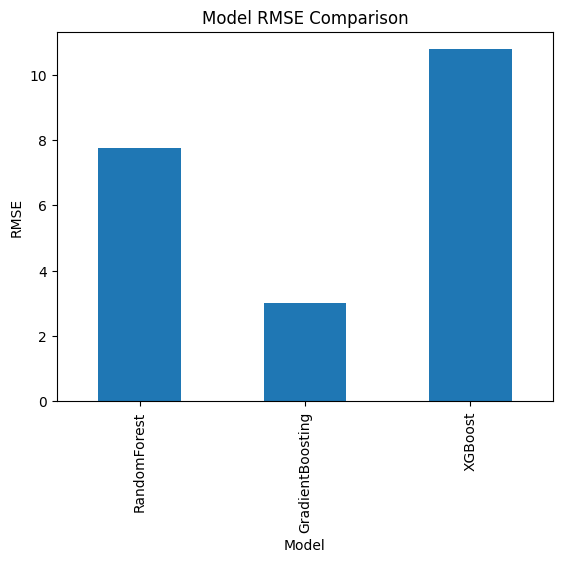

In [0]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False,
    title="Model RMSE Comparison"
)

plt.ylabel("RMSE")
plt.show()